<a href="https://colab.research.google.com/github/Luke-687/Simulating-Chemotaxis--Q-learning-and-Heuristic-/blob/main/Chemotaxis_Both_Models_(Abstract_figure).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Idea is to create a 100 by 100 space with a series of 5 randomly placed chemical gradient fields
#Create an agent beginning at a random location in the grid which will navigate through the space of many gradient fields
#Simulate the agent 5 times starting at random positions
#Visualize the randomly created gradient field as well as the 5 paths created to tell a story about microorganism navigation
#Do 5 paths for each model type (red for heuristic and blue for Q-learning)
import math
import random
import matplotlib.pyplot as plt

In [ ]:
#Heuristic Base Code (Refactored for the larger action space and with new gradient locations)

def defineSceneReward(xSize, ySize, gradientVals): #Work off the logic that the reward value is just gradient val multiplied by 10, and then when gradient val is 1, reward is 50 and when value is 0, reward is -50
  reward = []
  for x in range(xSize+1):
    for y in range(ySize+1):
      gradient = gradientVals[(xSize + ySize*100)]
      if(gradient==1):
        reward.append(50)
      elif(gradient==0):
        reward.append(-50)
      else:
        reward.append(10*gradient)
  return reward

def calculate_velocity(posX, posY, rewards):
  posX = int(posX)
  posY = int(posY)
  currentReward = rewards[posX+posY*20]
  if(currentReward<0):
    velocity = 4
  else:
    velocity = 1.5/currentReward
  if(velocity>=4):
    velocity = 4
  if(velocity<=1):
    velocity = 1
  return velocity


def calculate_direction(currentX, currentY, pastR, currentR, currentDirection, gradientVals, p): #p exists as a mathematical constant to provide ideal results
  change=0
  #Essential for later conditionals
  gradientValPos = gradientVals[(int(currentX) + int(currentY)*100)]

  if(not currentR==0 and not pastR==0):
    if(gradientValPos>0): #Meaning within any of the gradients
      change = 360*(abs(pastR/currentR)**0.8)*((random.choice([-1,1])))

    else:
      if(pastR>currentR):
        if(abs(pastR)<abs(currentR)):
          change = (180-180*(abs((pastR)/(currentR))**p))*((random.choice([-1,1,-1,-1,-1])))
        else:
          change = (180-180*(abs((currentR)/(pastR))**p))*((random.choice([-1,1,-1,-1,-1])))

  newDirection = (currentDirection+change)%360
  return (newDirection)

def brownianMotion():
  result = [0,0]
  xChange = random.random()/4
  yChange = random.random()/4
  for i in range(10):
    xChange+= random.random()/100 * (-1**(random.randint(1,2)))
    yChange+= random.random()/100 * (-1**(random.randint(1,2)))
  result = [xChange, yChange]
  return result


#Simualtion of the agent based around the rules and calculations provided by all function
def heuristicSimulate (alpha, gamma, xS, yS,steps, steep, gradientVals):
  #Define the initial parameters
  velocity = 4
  direction = random.randint(10,80)
  #Starting position is some (x,y) outside of gradient
  currentX = random.randint(1,100)
  currentY = random.randint(1,100)
  stepsToBeMade=steps

  #Working with the customized gradient field:
  reward = defineSceneReward(xS, yS, gradientVals)

  #This works as an adjustment to the direction recalculation
  p=0.59
  #This works as an adjustment to the alpha and gamma in updated rewards
  test = 3.75

  #Track x,y pos
  x=[]
  y=[]

  pastReward = 0
  for i in range(0, stepsToBeMade):
    #Enter and calculate reward of values which are about to be moved on from
    currentX = max(0, min(currentX, 99))
    currentY = max(0, min(currentY, 99))
    x.append(currentX)
    y.append(currentY)

    #Find new position, and new current reward (applu brownian and update rewards for future calculations)
    brownian = brownianMotion()
    changeX = velocity * math.cos(direction*math.pi/180) + brownian[0]
    changeY = velocity * math.sin(direction*math.pi/180) + brownian[1]
    currentX = x[-1] + changeX #past + change in position
    currentY = y[-1] + changeY #past + change in position
    currentX = max(0, min(currentX, 99))
    currentY = max(0, min(currentY, 99))
    currentReward = pastReward + test*alpha*(reward[int(currentX+currentY*20)]+test*gamma*(reward[int(currentX+currentY*20)]-pastReward))

    # Redefine velocity and direction for next steps --  refer to functions for better description
    velocity = calculate_velocity(int(currentX), int(currentY), reward)
    direction = calculate_direction(currentX, currentY, pastReward, currentReward, direction, gradientVals, p)
    pastReward = currentReward
  return x,y

In [ ]:
#Q-learning Base Code (Refactored for the larger action space and with new gradient locations)
#Agent class for everything

class agent:
  def __init__(self, alpha, gamma, epsilon, gradientVals, s):

    #Establish key parameters for training Q-Table and Q-Table itself
    self.alpha=alpha
    self.gamma=gamma
    self.epsilon = epsilon
    self.s = s
    self.gradientVals = gradientVals
    self.Qtable = {}
    for i1 in range(0,100):
      for j1 in range(0,100):
        for direction in range(0,8):
          for velocity in range(1,4):
            self.Qtable[((i1,j1),(direction, velocity))] = [0, self.moveForQTable(i1,j1, direction, velocity)]

  #Following 4 functions to define Q-table and train

  #Uses basic vector math and trigonometry in order to determine the next position based on current position and velocity (direction and speed)
  def moveForQTable(self, initX, initY, direction, velocity): # Added self
    direction = self.directionKey(direction) # Added self.
    return [(initX + int(math.cos(direction)*velocity)),(initY + int(math.sin(direction)*velocity))]


  #Converts angle direction stored in degrees in the model into radians for calculations using sin and cos
  def directionKey(self, direction): # Added self
    angle = direction*45
    return angle*math.pi/180


  #Based on an inverse relationship with distance from the center to define logical reward values
  def reward(self, x, y): # Added self
    reward = 0
    gradient = self.gradientVals[(int(x) + int(y)*100)]
    if(gradient==1):
      reward+= 50
    elif(gradient==0):
      reward+= 50
    else:
      reward += 10*gradient
    return reward


  #Random motion with a minimum of -0.35 and a maximum of 0.35 in both the x and y directions
  def brownianMotion(self):
    result = [0,0]
    xChange = random.random()/4
    yChange = random.random()/4
    for i in range(10):
      xChange+= random.random()/100 * (-1**(random.randint(1,2)))
      yChange+= random.random()/100 * (-1**(random.randint(1,2)))
    result = [xChange, yChange]
    return result


  #Run after the creation of a chemotaxis agent for a specific number of training episodes in order to establush a model to simulate based off of
  def trainQTable(self, trainingEpisodes, perc): #Perc variable defines the increase in percentage variability for the model outside the gradient (increase randomness)
    trainingRewards = [[],[]]
    for iterations in range(trainingEpisodes):
      totReward=0

      #Starting position some (x,y) at origin of system
      currentX = random.randint(1,99)
      currentY = random.randint(1,99)

      #Each training episode run with 50 steps of the agent
      for steps in range(0,900):

        #Maximize the reward of a certain "direction, velocity" from the current position
        direction, velocity = max(
            [(d,v) for d in range(8) for v in range(1,4)],
            key=lambda a: self.Qtable[(int(currentX),int(currentY)),a][0] # Convert to int
        )

        #Below is the implementation of the "perc" concept, increasing randomness outside gradient
        gradientVal = self.gradientVals[int(currentX) + int(currentY)*100]
        if(gradientVal == 0):
          tempEpsilon = self.epsilon+perc
          if(random.random()<tempEpsilon):
            direction = random.randint(0,7)
            velocity = random.randint(1,3)
        else:
          if(random.random()<self.epsilon):
            direction = random.randint(0,7)
            velocity = random.randint(1,3)

        #Use the optimized or random values for direction and velocity provided to calculate new position
        nextPos = self.moveForQTable(currentX, currentY, direction, velocity)
        #Apply Brownian motion to the next position
        XYBrown = self.brownianMotion()
        nextX = max(0, min(99, nextPos[0]+XYBrown[0]))
        nextY = max(0, min(99, nextPos[1]+XYBrown[1]))

        #Update the Q-Table, as simulations in this body of code are meant to provide information through convergence of perceived rewards by the Q-Learning agent -- (Reference Q-table update equation)
        initReward = self.reward(nextX, nextY)
        nextReward = max(
            self.Qtable[(int(nextX), int(nextY)), (d,v)][0] # Convert to int
            for d in range(8)
            for v in range(1,4)
        )
        self.Qtable[((int(currentX),int(currentY)),(direction, velocity))][0] = self.Qtable[((int(currentX),int(currentY)),(direction, velocity))][0] + self.alpha*(initReward + self.gamma*nextReward-self.Qtable[((int(currentX),int(currentY)),(direction, velocity))][0]) # Convert to int
        currentX = nextX
        currentY = nextY
        totReward+=self.Qtable[((int(currentX),int(currentY)),(direction, velocity))][0] + self.alpha*(initReward + self.gamma*nextReward-self.Qtable[((int(currentX),int(currentY)),(direction, velocity))][0]) # Convert to int
      trainingRewards[0].append(iterations)
      trainingRewards[1].append(totReward)
    return trainingRewards #For possible future analysis of how the total reward of the training process changes as the Q-table values converge to cause more optimal behavior


  #Following training of the Q-table, the model may be simulated
  def simulate(self, steps, perc): # Added self
    x=[]
    y=[]

    #Starting position is some (x,y) outside of gradient
    currentX = random.randint(1,99)
    currentY = random.randint(1,99)

    #Run for a certain number of steps
    for steps in range(0,steps):
      currentX = max(0, min(99, currentX))
      currentY = max(0, min(99, currentY))

      #For graphing later on:
      x.append(currentX)
      y.append(currentY)

      rewardOption = -100000
      currentX = int(currentX)
      currentY = int(currentY)
      nextPos = [currentX, currentY]

      #Calculate and compare for what direction and velocity may provide the maximum possible reward
      for direction in range(0,8):
        for velocity in range(1,4):
          testReward = self.Qtable[(currentX, currentY), (direction, velocity)][0]
          if(testReward>=rewardOption):
            rewardOption = testReward
            nextPos = self.Qtable[(currentX, currentY), (direction, velocity)][1]

      #Make the agent more random outside gradient:
      fromCenter = math.sqrt((currentX-9.5)**2+(currentY-9.5)**2)
      if(fromCenter>5):
        tempEpsilon = self.epsilon+perc
        if(random.random()<tempEpsilon):
          nextPos = self.Qtable[(currentX, currentY), (random.randint(0,7), random.randint(1,3))][1]

      #Apply brownian motion and save values as current x and y
      XYBrown = self.brownianMotion()
      currentX = nextPos[0] + XYBrown[0]
      currentY = nextPos[1] + XYBrown[1]
    return x,y


In [ ]:
#New specialized gradient function
class gradientField:
  def __init__(self, sizeX, sizeY, steepness):
    self.xSize = sizeX
    self.ySize = sizeY
    self.steepness = steepness
  def chemicalFieldCreate(self, num):
    fields = [] #Arrays saved to this in form [xCenter, yCenter, radius]
    for field in range(num):
      fields.append([random.randint(1,100), random.randint(1,100), random.randint(4,7)])
    return fields
  def gradientVal(self, x, y, chemicalFields):
    gradVal = 0
    for field in range(len(chemicalFields)):
      fieldX = chemicalFields[field][0]
      fieldY = chemicalFields[field][1]
      fieldR = chemicalFields[field][2]
      distCent = math.sqrt((x-fieldX)**2+(y-fieldY)**2)
      if(distCent<=fieldR):
        if(not distCent == 0):
          gradVal+= 1/(distCent**self.steepness)
        else:
           gradVal+=1
    if(gradVal>=1):
      return 1
    else:
      return gradVal
  def createGradient(self, num):
    xG = [] #All x values of points in grid
    yG = [] #All y values of points in grid
    alphaG = [] #All gradient values of points in grid
    chemicalFields = self.chemicalFieldCreate(num) #Num randomized chemical field locations
    for x in range(self.xSize+1):
      for y in range(self.ySize+1):
        xG.append(x)
        yG.append(y)
        alphaG.append(self.gradientVal(x,y,chemicalFields))
    return xG, yG, alphaG

In [ ]:
epsilon = 0.15
perc = 0.25
steep = 0.75

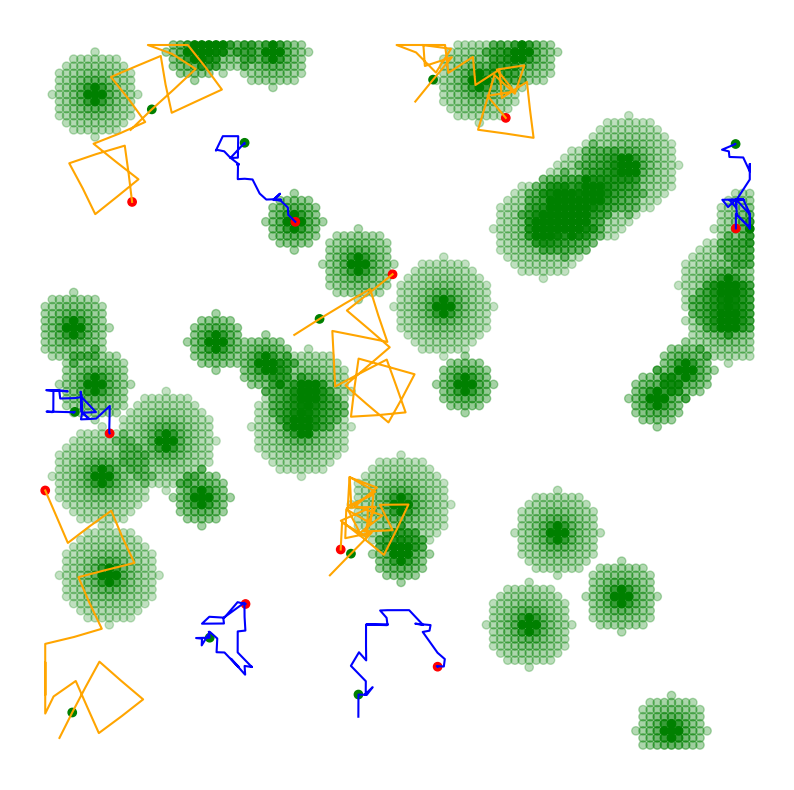

In [ ]:
#Define figure size
plt.figure(figsize=(10, 10))
plt.axis('off')

#Create gradient with values for simulation
gradient = gradientField(99,99, 0.75)
xG, yG, alphaG = gradient.createGradient(35)
plt.scatter(xG, yG, color = 'green', alpha = alphaG)

#Create 5 heuristic model pathways
for simulate in range(5):
  xSim, ySim = heuristicSimulate(0.6, 0.6, 99, 99, 30, steep, alphaG)
  plt.plot(xSim, ySim, color = 'orange')
  plt.scatter((xSim[1],xSim[-1]), [ySim[1], ySim[-1]], color = ["green", "red"])
#Create 5 Q-learning model pathways
for simulate in range(5):
  tempModel = agent(0.99, 0.99, epsilon, alphaG, 0.75)
  tempModel.trainQTable(1000, perc)
  xSim, ySim = tempModel.simulate(30, perc)
  plt.plot(xSim, ySim, color = 'blue')
  plt.scatter((xSim[1],xSim[-1]), [ySim[1], ySim[-1]], color = ["green", "red"])